QUESTÃO III - OBSERVAÇÕES:
Peguei o dataset no Kaggle. link: 
Disponibilizo os modelos para download no meu google drive:
Professor, infelizmente não consegui pensar em nada pra possibilitar um link online com os arquivos, para que sua execução pudesse ser feita sem ter que mexer, baixar ou configurar nada. O Sr. pode fazer o download do dataset pelos links acima, caso queira executar o train, o arquivo está dentro do ZIP que disponibilizei no classroom ´´´´ task04_q3_train_vc_mestrado.ipynb ´´´.

O link para os 3 modelos (VGG, RESNET50, MOBILEV2) zipados: 

QUESTÃO III - A
Geramos o HOG,


QUESTÃO III - B
Utilizei como solicitado no enunciado da questão transferência de aprendizado com VGG16, ResNet50 e MobileNetV2 do PyTorch. Eu tentei gerar um modelo manual, na verdade consegui rodar no meu notebook localmente, mas todas as vezes não passava das 40 epochs o meu notebook fechava tudo, killaba. Mas com 37 epochs que foi até onde chegou pegou 0.95. Então criei uma instância na ec2 e gerei 3 modelos, os quais vão ser executados aqui na questão B. Para agilizar o pytorch já tem seus pesos pré-treinados em ImageNet. então me bastou definir a última camada para classificar gatos e cachorros (2), isso porque as libs já tem arquiteturas pré definidas então as camadas convolucionais são bem otimizadas, isso reflete nos resultados, poucas epochs temos altos índices de acurácia e precisão, loss constante. Apliquei uma pequena lógica pra salvar o melhor resultado, as vezes quando não usamos o stop pra pouca diferença no loss e validação, eu vou salvando o melhor modelo e pronto. Se nenhum bater, aquele é. 

In [2]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import joblib

from PIL import UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchinfo import summary
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC


In [3]:
df_dir = '/home/ubuntu/visao-computacional/PetImages'

cat_files = os.listdir(os.path.join(df_dir, 'Cat'))
dog_files = os.listdir(os.path.join(df_dir, 'Dog'))

In [4]:
# limpar algumas imagens corrompidas do df
for folder in ['Cat', 'Dog']:
    folder_path = os.path.join(df_dir, folder)
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            with Image.open(file_path) as img:
                img.verify()
        except (IOError, SyntaxError, UnidentifiedImageError, ValueError):
            os.remove(file_path)

/home/ubuntu/visao-computacional/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [5]:
# Split do dataset, train 0.7 e val 0.3
full_dataset = ImageFolder(df_dir, transform=None)
train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_indices, val_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
    )

# Por Motivos de desempenho do meu notebook local em quesito cpu, vou testar o algoritmo com uma redução considerável de dados
# Torno ele ajustável através dos inputs:
train_length = 0.3
val_length = 0.3

train_limit = int(train_length * len(train_indices))
val_limit = int(val_length * len(val_indices))

limited_train_indices = train_indices.indices[:train_limit]
limited_val_indices = val_indices.indices[:val_limit]

train_paths, train_labels = [], []
val_paths, val_labels = [], []

for idx in limited_train_indices:
    path, label = full_dataset.samples[idx]
    train_paths.append(path)
    train_labels.append(label)
for idx in limited_val_indices:
    path, label = full_dataset.samples[idx]
    val_paths.append(path)
    val_labels.append(label)

Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 226 extraneous bytes before marker 0xd9


Acurácia HOG+SVM: 0.66


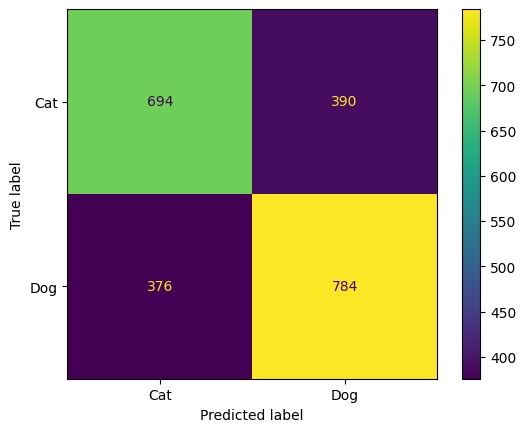

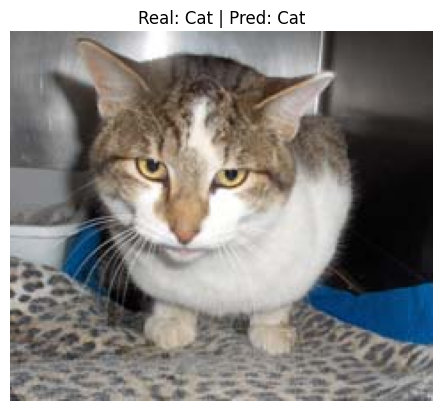

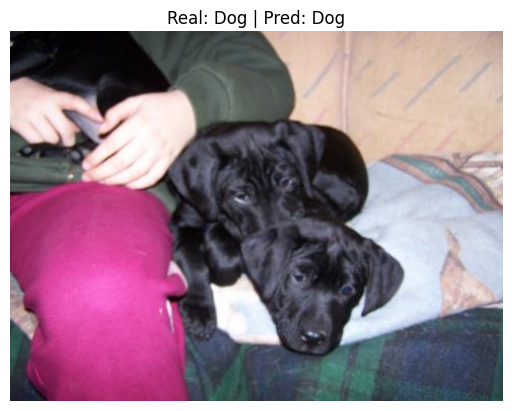

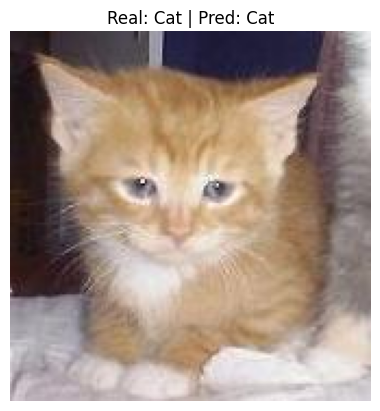

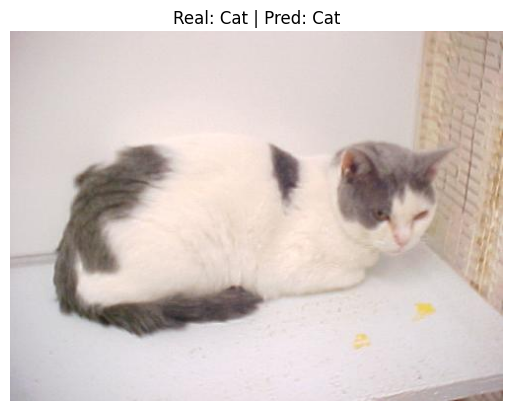

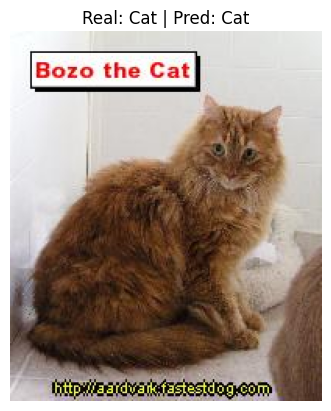

['hog_svm_model.joblib']

In [6]:
# Função para extrair HOG
hog = cv2.HOGDescriptor()
def extract_hog(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (128, 128))
    return hog.compute(img).flatten()

# Use apenas os índices limitados!
train_paths, train_labels = [], []
val_paths, val_labels = [], []

for idx in limited_train_indices:
    path, label = full_dataset.samples[idx]
    train_paths.append(path)
    train_labels.append(label)
for idx in limited_val_indices:
    path, label = full_dataset.samples[idx]
    val_paths.append(path)
    val_labels.append(label)

# Extrai HOG
X_train = [extract_hog(p) for p in train_paths]
X_val = [extract_hog(p) for p in val_paths]

# Remove imagens corrompidas (None)
train_valid = [(x, y, p) for x, y, p in zip(X_train, train_labels, train_paths) if x is not None]
val_valid = [(x, y, p) for x, y, p in zip(X_val, val_labels, val_paths) if x is not None]
X_train, y_train, train_paths = zip(*train_valid)
X_val, y_val, val_paths = zip(*val_valid)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_val = np.array(X_val)
y_val = np.array(y_val)

# Treina SVM
clf = LinearSVC(max_iter=10000)
clf.fit(X_train, y_train)

# Avaliação
y_pred = clf.predict(X_val)
acc = accuracy_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)
print(f'Acurácia HOG+SVM: {acc:.2f}')
ConfusionMatrixDisplay(cm, display_labels=full_dataset.classes).plot()
plt.show()

# Exibe exemplos de acerto e erro
for i in range(5):
    idx = np.where(y_val == y_pred)[0][i]
    img = cv2.imread(val_paths[idx])
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Real: {full_dataset.classes[y_val[idx]]} | Pred: {full_dataset.classes[y_pred[idx]]}')
    plt.axis('off')
    plt.show()

joblib.dump(clf, 'hog_svm_model.joblib')